In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# USER SETUP:
# Upload energydata_complete.csv to MyDrive.
# If you use a different Drive folder, change only DATA_PATH below.

DATA_PATH = "/content/drive/MyDrive/energydata_complete.csv"

RESULT_PATH = "/content/drive/MyDrive/appliances_energy_model_results.csv"
PREDICTION_PATH = "/content/drive/MyDrive/appliances_energy_predictions.csv"
IMPORTANCE_PATH = "/content/drive/MyDrive/appliances_energy_feature_importance.csv"

R2_GRAPH_PATH = "/content/drive/MyDrive/appliances_energy_r2_comparison.png"
PRED_GRAPH_PATH = "/content/drive/MyDrive/appliances_energy_actual_vs_predicted.png"
IMPORTANCE_GRAPH_PATH = "/content/drive/MyDrive/appliances_energy_feature_importance.png"

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload energydata_complete.csv to Google Drive or update DATA_PATH."
    )

In [4]:
# Load and inspect the raw dataset.
df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df.shape)
display(df.head())
print("\nMissing values:", int(df.isna().sum().sum()))
print("\nTarget summary (Appliances, Wh):")
display(df["Appliances"].describe().to_frame().T)

Original dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097



Missing values: 0

Target summary (Appliances, Wh):


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.0,50.0,60.0,100.0,1080.0


In [5]:
# Time-based feature engineering.
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

df["hour_sin"] = np.sin(2 * np.pi * df["date"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["date"].dt.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofweek / 7)
df["month"] = df["date"].dt.month

# rv1 and rv2 are documented random variables in the UCI dataset,
# so they are excluded from the predictive feature set.
drop_cols = ["date", "Appliances", "rv1", "rv2"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["Appliances"].astype(float)

print("Model input shape:", X.shape)
print("Number of predictors:", X.shape[1])
display(X.head())

Model input shape: (19735, 30)
Number of predictors: 30


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour_sin,hour_cos,dow_sin,dow_cos,month
0,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,733.5,92.0,7.000000,63.000000,5.3,-0.965926,-0.258819,0.0,1.0,1
1,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,733.6,92.0,6.666667,59.166667,5.2,-0.965926,-0.258819,0.0,1.0,1
2,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,733.7,92.0,6.333333,55.333333,5.1,-0.965926,-0.258819,0.0,1.0,1
3,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,733.8,92.0,6.000000,51.500000,5.0,-0.965926,-0.258819,0.0,1.0,1
4,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,733.9,92.0,5.666667,47.666667,4.9,-0.965926,-0.258819,0.0,1.0,1


In [6]:
# Chronological 80/20 split.
split_point = int(len(X) * 0.80)

X_train = X.iloc[:split_point].copy()
X_test = X.iloc[split_point:].copy()
y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Train period:", df.loc[:split_point - 1, "date"].min(), "to", df.loc[:split_point - 1, "date"].max())
print("Test period:", df.loc[split_point:, "date"].min(), "to", df.loc[split_point:, "date"].max())

Training rows: 15788
Testing rows: 3947
Train period: 2016-01-11 17:00:00 to 2016-04-30 08:10:00
Test period: 2016-04-30 08:20:00 to 2016-05-27 18:00:00


In [7]:
# Both algorithms benefit from standardised predictors.
# The target is also standardised internally and automatically transformed
# back to Wh when predictions are produced.

linear_svr = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scale_x", StandardScaler()),
        ("model", LinearSVR(
            C=1.0,
            epsilon=0.1,
            loss="squared_epsilon_insensitive",
            random_state=42,
            max_iter=20000
        ))
    ]),
    transformer=StandardScaler()
)

neural_net = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scale_x", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=250,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=20,
            random_state=42
        ))
    ]),
    transformer=StandardScaler()
)

models = {
    "Linear SVR": linear_svr,
    "MLP Neural Network": neural_net
}

In [8]:
# Train and evaluate both models.
results = []
prediction_table = pd.DataFrame({"Actual": y_test.to_numpy()})
fitted_models = {}

for model_name, model in models.items():
    print(f"Training {model_name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    prediction_table[model_name] = y_pred
    fitted_models[model_name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\nModel comparison:")
display(results_df.round(4))

Training Linear SVR ...
Training MLP Neural Network ...

Model comparison:


,Model,MAE,RMSE,R2
0,Linear SVR,47.3186,84.6618,0.1352
1,MLP Neural Network,141.9905,198.3314,-3.7461


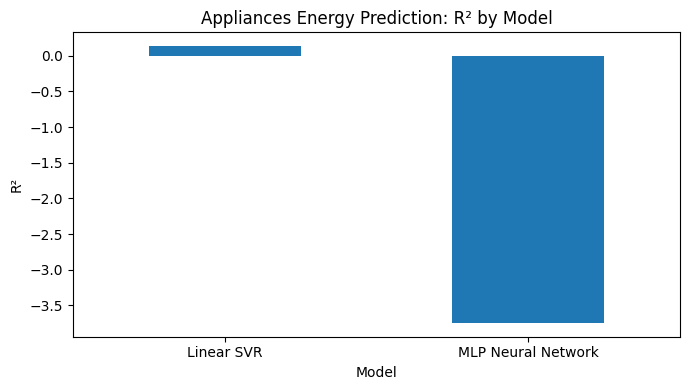

In [9]:
# Graph 1: R² comparison.
ax = results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    rot=0
)
ax.set_title("Appliances Energy Prediction: R² by Model")
ax.set_xlabel("Model")
ax.set_ylabel("R²")
plt.tight_layout()
plt.savefig(R2_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

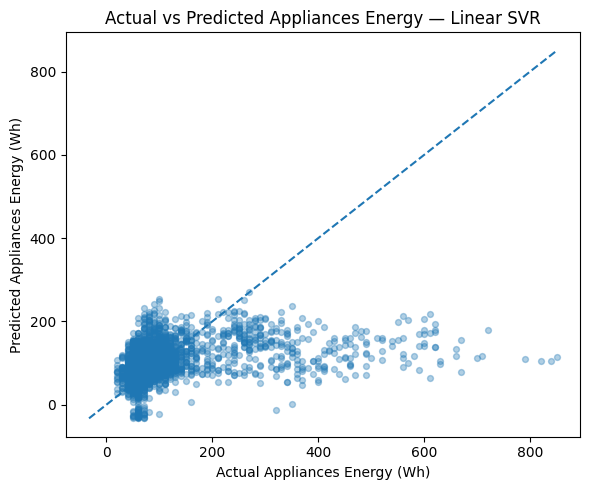

In [10]:
# Graph 2: Actual versus predicted values for the lower-RMSE model.
best_model_name = results_df.loc[0, "Model"]
best_predictions = prediction_table[best_model_name].to_numpy()

plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_predictions, alpha=0.35, s=18)

lower = min(float(y_test.min()), float(best_predictions.min()))
upper = max(float(y_test.max()), float(best_predictions.max()))
plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.title(f"Actual vs Predicted Appliances Energy — {best_model_name}")
plt.xlabel("Actual Appliances Energy (Wh)")
plt.ylabel("Predicted Appliances Energy (Wh)")
plt.tight_layout()
plt.savefig(PRED_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

Top predictors for Linear SVR:


,Feature,Importance
0,RH_2,46.5182
1,RH_1,23.9869
2,T2,23.0805
3,T3,17.2212
4,RH_3,11.4413
5,T9,10.6533
6,hour_cos,10.3139
7,RH_4,3.7915
8,RH_out,3.3608
9,RH_8,1.8715


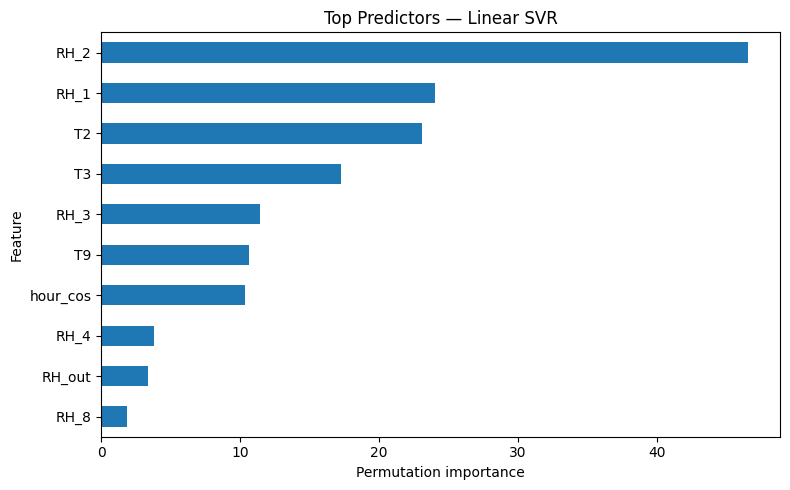

In [11]:
# Model-agnostic insight: permutation importance for the best model.
# A limited test sample keeps this step quick enough for Colab.
best_model = fitted_models[best_model_name]

sample_n = min(2000, len(X_test))
X_imp = X_test.iloc[:sample_n]
y_imp = y_test.iloc[:sample_n]

perm = permutation_importance(
    best_model,
    X_imp,
    y_imp,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(f"Top predictors for {best_model_name}:")
display(importance_df.round(4))

ax = importance_df.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)
ax.set_title(f"Top Predictors — {best_model_name}")
ax.set_xlabel("Permutation importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(IMPORTANCE_GRAPH_PATH, dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# Save outputs to Google Drive.
results_df.to_csv(RESULT_PATH, index=False)
prediction_table.to_csv(PREDICTION_PATH, index=False)
importance_df.to_csv(IMPORTANCE_PATH, index=False)

print("Saved:")
print("-", RESULT_PATH)
print("-", PREDICTION_PATH)
print("-", IMPORTANCE_PATH)
print("-", R2_GRAPH_PATH)
print("-", PRED_GRAPH_PATH)
print("-", IMPORTANCE_GRAPH_PATH)

Saved:
- /content/drive/MyDrive/appliances_energy_model_results.csv
- /content/drive/MyDrive/appliances_energy_predictions.csv
- /content/drive/MyDrive/appliances_energy_feature_importance.csv
- /content/drive/MyDrive/appliances_energy_r2_comparison.png
- /content/drive/MyDrive/appliances_energy_actual_vs_predicted.png
- /content/drive/MyDrive/appliances_energy_feature_importance.png
